# Модель M/M/c

**Авторы:** А. В. Королькова, PhD, Кулябов Д. С., DSc

**Принадлежность:** Российский университет дружбы народов

## Назначение скрипта

Данный скрипт реализует дискретно-событийную симуляцию системы массового
обслуживания M/M/c (по классификации Кендалла).

### Что делает скрипт

1. Моделирует пуассоновский входящий поток заявок с интенсивностью λ

2. Моделирует экспоненциальное обслуживание с интенсивностью μ на c серверах

3. Собирает статистику о времени ожидания и времени обслуживания

4. Строит графики распределений и сходимости средних

5. Сохраняет результаты в CSV и PNG

### Характеристики модели M/M/c

| Свойство | Описание |
|----------|----------|
| Входящий поток | Пуассоновский (M) |
| Обслуживание | Экспоненциальное (M) |
| Число серверов | c (2) |
| Дисциплина очереди | FIFO |

## Параметры модели

| Параметр | Значение | Описание |
|----------|----------|----------|
| num_customers | 100 | Количество клиентов |
| num_servers (c) | 2 | Число серверов |
| λ | 0.9 | Интенсивность входящего потока |
| μ | 0.5 | Интенсивность обслуживания (1 сервера) |
| ρ = λ/(c·μ) | 0.9 | Загрузка системы |
| seed | 123 | Зерно генератора случайных чисел |

## Выходные данные

| Файл | Описание |
|------|----------|
| `data/mmc/results.csv` | DataFrame с временами прибытия, ожидания, обслуживания |
| `plots/mmc_analysis.png` | Составной график (3 панели) — рис. 7.1 |

## Интерпретация результатов

### График 1: Распределение времени ожидания

Показывает, сколько клиентов ждали в очереди определённое время.
При ρ=0.9 очередь будет значительной.

### График 2: Распределение времени обслуживания

Экспоненциальное распределение с параметром μ=0.5 (среднее = 2).

### График 3: Сходимость среднего времени ожидания

Демонстрирует, как накопленное среднее стабилизируется с ростом числа клиентов,
что свидетельствует о выходе системы в стационарный режим.

## Инициализация проекта DrWatson

In [1]:
using DrWatson
@quickactivate "project"

## Загрузка необходимых пакетов

In [2]:
using StableRNGs, Distributions, ConcurrentSim, ResumableFunctions
using DataFrames, CSV, Plots

## Задание параметров симуляции

Все параметры вынесены в начало для удобства модификации.
Используется StableRNG для воспроизводимости результатов.

In [3]:
rng = StableRNG(123)
num_customers = 100
num_servers = 2
mu = 1.0 / 2
lam = 0.9
arrival_dist = Exponential(1 / lam)
service_dist = Exponential(1 / mu)

Distributions.Exponential{Float64}(θ=2.0)

## Хранилище для сбора данных

В массив `records` будут помещаться кортежи с данными о каждом клиенте.

In [4]:
records = []

Any[]

## Поведение клиента

Каждый клиент проходит следующие этапы:
1. Ожидание времени прибытия (timeout)
2. Запрос сервера (request)
3. Ожидание окончания обслуживания (timeout)
4. Освобождение сервера (unlock)
5. Запись временных меток в records

In [5]:
@resumable function customer(env, server, id, t_a, d_s)
    @yield timeout(env, t_a)
    t_arr = now(env)
    @yield request(server)
    t_start = now(env)
    @yield timeout(env, rand(rng, d_s))
    t_end = now(env)
    @yield unlock(server)
    push!(records, (id=id, arrival=t_arr, start=t_start, finish=t_end,
                    wait_time=t_start - t_arr, service_time=t_end - t_start))
end

customer (generic function with 1 method)

## Запуск симуляции

Функция создаёт среду, ресурс-сервер, инициализирует клиентов и запускает
дискретно-событийную симуляцию.

In [6]:
function run_simulation()
    sim = Simulation()
    server = Resource(sim, num_servers)
    arrival_time = 0.0
    for i = 1:num_customers
        arrival_time += rand(rng, arrival_dist)
        @process customer(sim, server, i, arrival_time, service_dist)
    end
    run(sim)
end

run_simulation()

## Сохранение результатов

Преобразование массива записей в DataFrame и сохранение в CSV-файл.

In [7]:
df = DataFrame(records)
mkpath(datadir("mmc"))
CSV.write(datadir("mmc", "results.csv"), df)
default(show=true, fmt=:png)

## Построение графиков

### График 1: Гистограмма времени ожидания

Показывает распределение времени, которое клиенты провели в очереди.

Could not create decoration from factory! Running with no decorations.


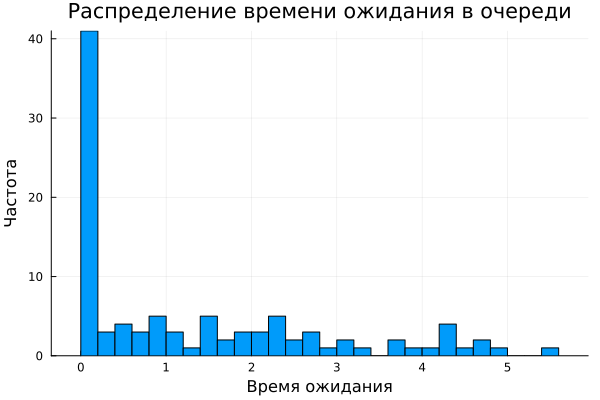

In [8]:
p1 = histogram(df.wait_time, bins=30,
               xlabel="Время ожидания", ylabel="Частота",
               title="Распределение времени ожидания в очереди",
               legend=false)

### График 2: Гистограмма времени обслуживания

Показывает распределение времени обслуживания (экспоненциальное).

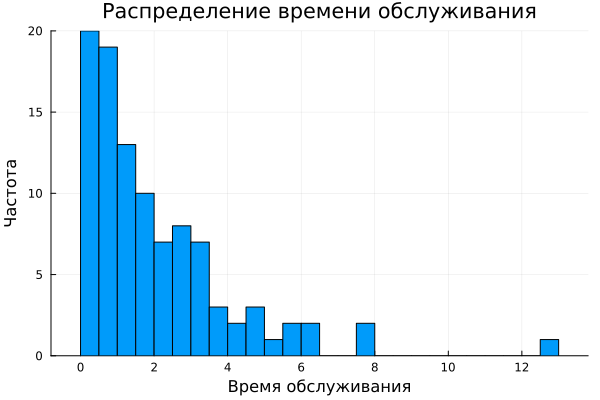

In [9]:
p2 = histogram(df.service_time, bins=30,
               xlabel="Время обслуживания", ylabel="Частота",
               title="Распределение времени обслуживания",
               legend=false)

### График 3: Сходимость среднего

Накопленное среднее время ожидания. Должно выходить на постоянное значение.

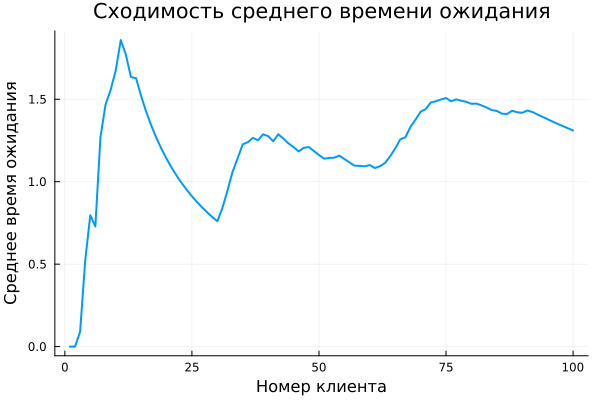

In [10]:
cumulative_avg = [mean(df.wait_time[1:i]) for i in 1:nrow(df)]
p3 = plot(1:nrow(df), cumulative_avg,
          xlabel="Номер клиента", ylabel="Среднее время ожидания",
          title="Сходимость среднего времени ожидания",
          legend=false, linewidth=2)

### Объединение графиков

Все три графика располагаются вертикально (3 строки, 1 столбец).

In [11]:
p_final = plot(p1, p2, p3, layout=(3,1), size=(600, 900))
mkpath(plotsdir())
savefig(plotsdir("mmc_analysis.png"))

"/home/mmulitina/work/study/2026-1/backup/2026-1-study-simulation-modeling/labs/lab07/project/plots/mmc_analysis.png"

## Вывод статистики в консоль

In [12]:
println("Среднее время ожидания в очереди: ", round(mean(df.wait_time), digits=3))
println("Среднее время обслуживания: ", round(mean(df.service_time), digits=3))
println("Среднее время в системе: ", round(mean(df.service_time + df.wait_time), digits=3))
println("Количество обслуженных клиентов: ", nrow(df))
println("\nГрафик сохранён: plots/mmc_analysis.png")
println("Данные сохранены: data/mmc/results.csv")

Среднее время ожидания в очереди: 1.311
Среднее время обслуживания: 2.026
Среднее время в системе: 3.337
Количество обслуженных клиентов: 100

График сохранён: plots/mmc_analysis.png
Данные сохранены: data/mmc/results.csv
